# Du-Escanciano (2017) on the S&P 500

End-to-end replication of the unconditional and conditional Expected Shortfall backtests of Du and Escanciano (2017) on the S&P 500, extended to the COVID-19 window. The notebook fits AR(1)-GARCH(1,1) with Student-t innovations on each in-sample window, computes the out-of-sample PIT residuals, runs the eleven-test battery, and exports three headline figures.

In [1]:

import yaml
from IPython.display import display

from esback.backtests.battery import run_full_battery
from esback.backtests.es_baselines import StandardizedTSimulator
from esback.config import REPO_ROOT
from esback.data.loaders import load_sp500
from esback.pipeline import run_period
from esback.reporting.tables import comparison_table
from esback.risk_measures import es_t as compute_es_t
from esback.risk_measures import var_t as compute_var_t
from esback.viz import figures, style

style.apply_rcparams()
ASSETS_FIG = REPO_ROOT / "assets" / "figures"
ASSETS_FIG.mkdir(parents=True, exist_ok=True)

cfg = yaml.safe_load((REPO_ROOT / "configs" / "replication_du_escanciano.yaml").read_text())
alpha_es = cfg["backtest"]["alpha_es"]
alpha_var = cfg["backtest"]["alpha_var"]
m = cfg["backtest"]["m"]
alpha_es, alpha_var, m

(0.1, 0.05, 5)

## Data

`load_sp500` is wrapped in a parquet cache so repeated calls are bit-stable across yfinance back-fills.

In [2]:
data = load_sp500(start=cfg["data"]["start"], end=cfg["data"]["end"])
print(f"S&P 500: {len(data)} observations from {data.index[0].date()} to {data.index[-1].date()}")
data.tail()

S&P 500: 7044 observations from 1997-01-03 to 2024-12-30


Price,Close,Return
Date,,
2024-12-23,5974.069824,0.726085
2024-12-24,6040.040039,1.098223
2024-12-26,6037.589844,-0.040574
2024-12-27,5970.839844,-1.111730
2024-12-30,5906.939941,-1.075967


## Fit and forecast

Fit AR(1)-GARCH(1,1)-t on each in-sample window and reconstruct the out-of-sample PIT residuals, VaR and ES paths.

In [3]:
artifacts = {}
for period_cfg in cfg["periods"]:
    artifacts[period_cfg["name"]] = run_period(
        data,
        is_start=period_cfg["is_start"],
        is_end=period_cfg["is_end"],
        oos_end=period_cfg["oos_end"],
        label=period_cfg["name"],
        alpha_es=alpha_es,
        alpha_var=alpha_var,
        m=m,
    )

for name, a in artifacts.items():
    print(
        f"{name}: nu={a.fit.params['nu']:.2f}, n_oos={len(a.u_t)}, "
        f"n_violations={int(a.h_t.sum())}/{len(a.h_t)}"
    )

Period 1 - 2008 Financial Crisis: nu=8.72, n_oos=504, n_violations=44/504
Period 2 - COVID-19 Crash: nu=4.83, n_oos=505, n_violations=40/505


## Backtest battery

Eleven tests evaluated on each out-of-sample window. The Acerbi-Szekely and McNeil-Frey statistics expect ``alpha_VaR == alpha_ES``, so we re-evaluate VaR and ES at ``alpha_var`` for those tests while the Du-Escanciano statistics keep their ``alpha_ES = 2 * alpha_VaR`` convention.

In [4]:
batteries = {}
for name, a in artifacts.items():
    var_at_var = compute_var_t(a.forecast.mu_oos, a.forecast.sigma_oos, alpha_var, a.forecast.nu)
    es_at_var = compute_es_t(a.forecast.mu_oos, a.forecast.sigma_oos, alpha_var, a.forecast.nu)
    sim = StandardizedTSimulator(a.forecast.mu_oos, a.forecast.sigma_oos, a.forecast.nu)
    batteries[name] = run_full_battery(
        u_t=a.u_t,
        oos_returns=a.forecast.oos_returns,
        var_t=var_at_var,
        es_t=es_at_var,
        sigma_oos=a.forecast.sigma_oos,
        h_t=a.h_t,
        alpha_es=alpha_es,
        alpha_var=alpha_var,
        m=m,
        fit=a.fit,
        returns_all=a.returns_all,
        is_end_idx=a.is_end_idx,
        oos_end_idx=a.oos_end_idx,
        es_simulator=sim,
        n_sim=10_000,
        n_bootstrap=10_000,
    )

comp = comparison_table(batteries).round(4)
display(comp)
print(comp.to_markdown())

Period 1 - 2008 Financial Crisis                \
                                          statistic p_value alpha   
name                                                                
U_ES                                         4.1968  0.0000  0.10   
C_ES(5)                                     14.9532  0.0106  0.10   
U_VaR                                        3.8423  0.0001  0.05   
C_VaR(5)                                     9.5390  0.0894  0.05   
MU_ES                                        3.7395  0.0002  0.10   
MC_ES(5)                                    14.8936  0.0108  0.10   
Kupiec_POF                                  12.1945  0.0005  0.05   
Christoffersen_CCI                           3.4167  0.0645  0.05   
Christoffersen_CC                           15.6112  0.0004  0.05   
KLM_multinomial(4)                          23.3104  0.0001  0.10   
AS_Z1                                        0.0380  0.2168   NaN   
AS_Z2                                        0.8124  0.0002  0.05   
McNeil_Frey                                  1.0796  0.2759   NaN   

                                   Period 2 - COVID-19 Crash                \
                          decision                 statistic p_value alpha   
name                                                                         
U_ES                        REJECT                    2.3129  0.0207  0.10   
C_ES(5)                     REJECT                   13.8442  0.0166  0.10   
U_VaR                       REJECT                    3.0116  0.0026  0.05   
C_VaR(5)            Fail to reject                   17.0723  0.0044  0.05   
MU_ES                       REJECT                    2.2049  0.0275  0.10   
MC_ES(5)                    REJECT                   12.6821  0.0265  0.10   
Kupiec_POF                  REJECT                    7.7625  0.0053  0.05   
Christoffersen_CCI  Fail to reject                    1.0836  0.2979  0.05   
Christoffersen_CC           REJECT                    8.8461  0.0120  0.05   
KLM_multinomial(4)          REJECT                   13.5039  0.0091  0.10   
AS_Z1               Fail to reject                    0.0991  0.1021   NaN   
AS_Z2                       REJECT                    0.7412  0.0004  0.05   
McNeil_Frey         Fail to reject                    1.3609  0.1721   NaN   

                                    
                          decision  
name                                
U_ES                        REJECT  
C_ES(5)                     REJECT  
U_VaR                       REJECT  
C_VaR(5)                    REJECT  
MU_ES                       REJECT  
MC_ES(5)                    REJECT  
Kupiec_POF                  REJECT  
Christoffersen_CCI  Fail to reject  
Christoffersen_CC           REJECT  
KLM_multinomial(4)          REJECT  
AS_Z1               Fail to reject  
AS_Z2                       REJECT  
McNeil_Frey         Fail to reject

| name               |   ('Period 1 - 2008 Financial Crisis', 'statistic') |   ('Period 1 - 2008 Financial Crisis', 'p_value') |   ('Period 1 - 2008 Financial Crisis', 'alpha') | ('Period 1 - 2008 Financial Crisis', 'decision')   |   ('Period 2 - COVID-19 Crash', 'statistic') |   ('Period 2 - COVID-19 Crash', 'p_value') |   ('Period 2 - COVID-19 Crash', 'alpha') | ('Period 2 - COVID-19 Crash', 'decision')   |
|:-------------------|----------------------------------------------------:|--------------------------------------------------:|------------------------------------------------:|:---------------------------------------------------|---------------------------------------------:|-------------------------------------------:|-----------------------------------------:|:--------------------------------------------|
| U_ES               |                                              4.1968 |                                            0      |                                            0.

## Figures

Three figures exported to ``assets/figures/`` for the README gallery.

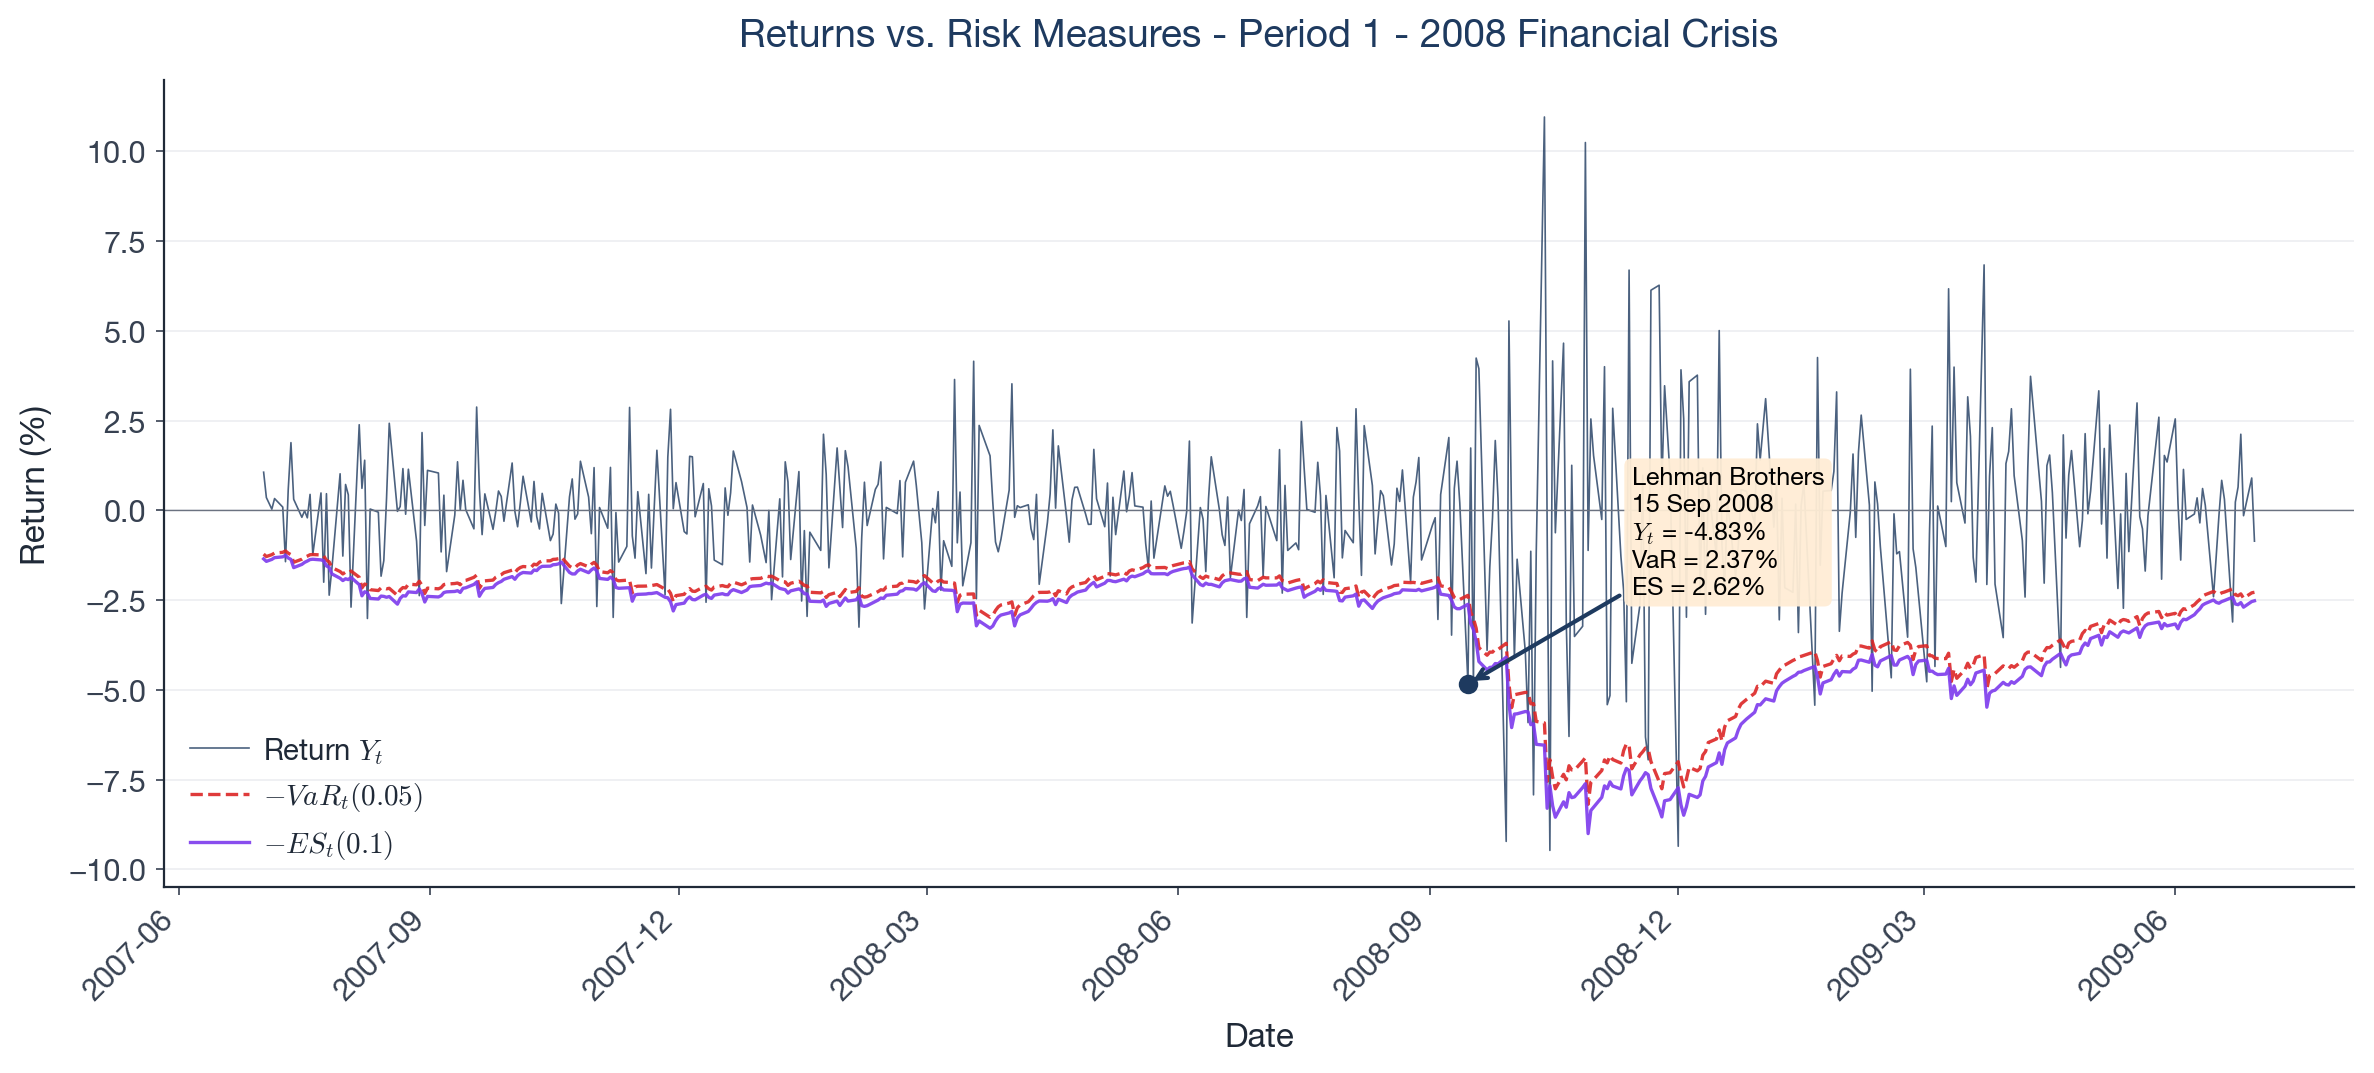

In [5]:
p1_name, p2_name = list(artifacts.keys())
p1, p2 = artifacts[p1_name], artifacts[p2_name]

_ = figures.plot_returns_var_es(
    p1.forecast.oos_index,
    p1.forecast.oos_returns,
    p1.var_t,
    p1.es_t,
    label=p1.label,
    zoom_date=cfg["periods"][0].get("figure_zoom_date"),
    zoom_label=cfg["periods"][0].get("figure_zoom_label"),
    alpha_var=alpha_var,
    alpha_es=alpha_es,
    save_to=ASSETS_FIG / "01_returns_var_es_2008.png",
)

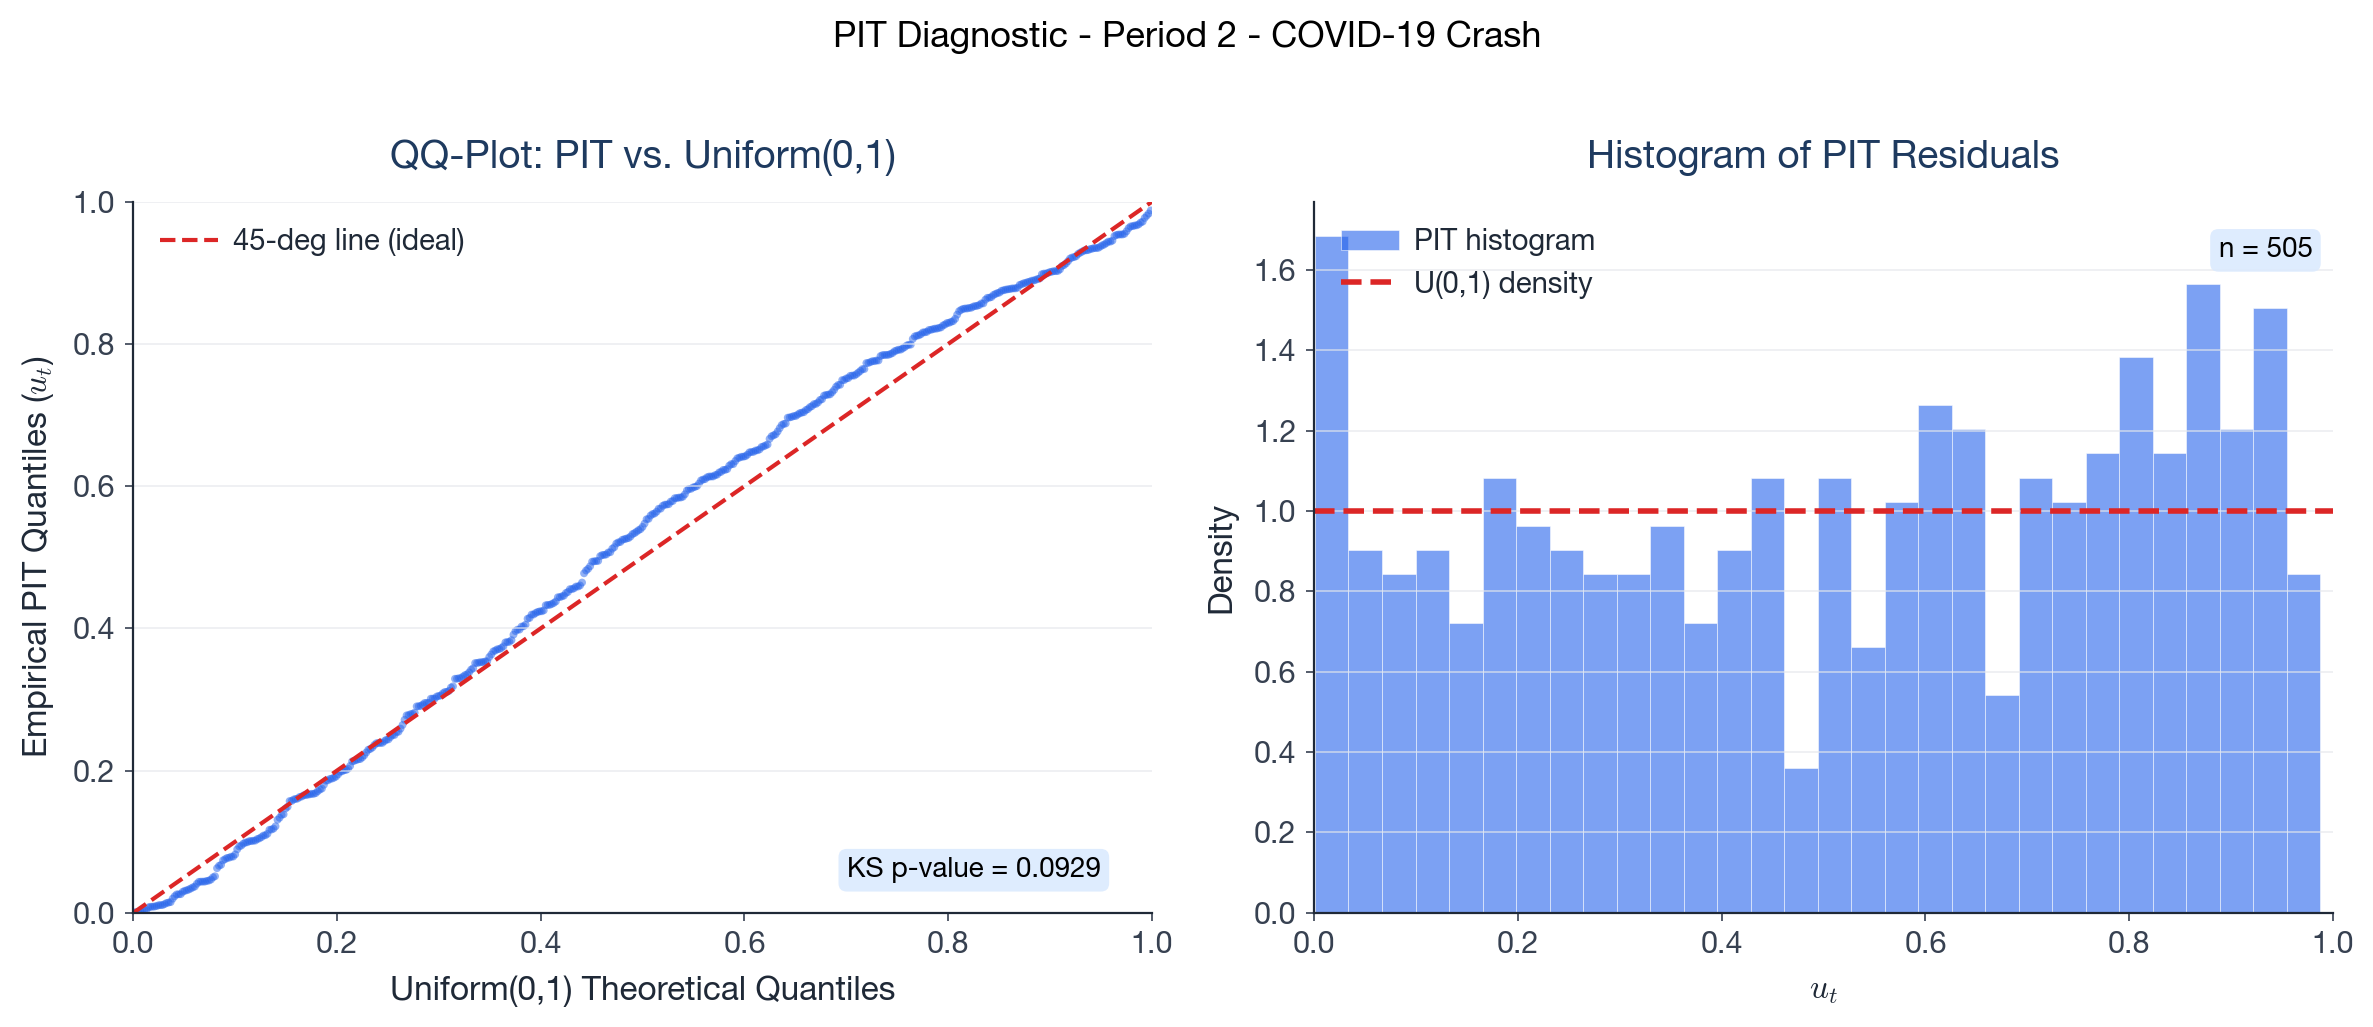

In [6]:
_ = figures.plot_pit_diagnostic(
    p2.u_t,
    label=p2.label,
    save_to=ASSETS_FIG / "01_pit_diagnostic_covid.png",
)

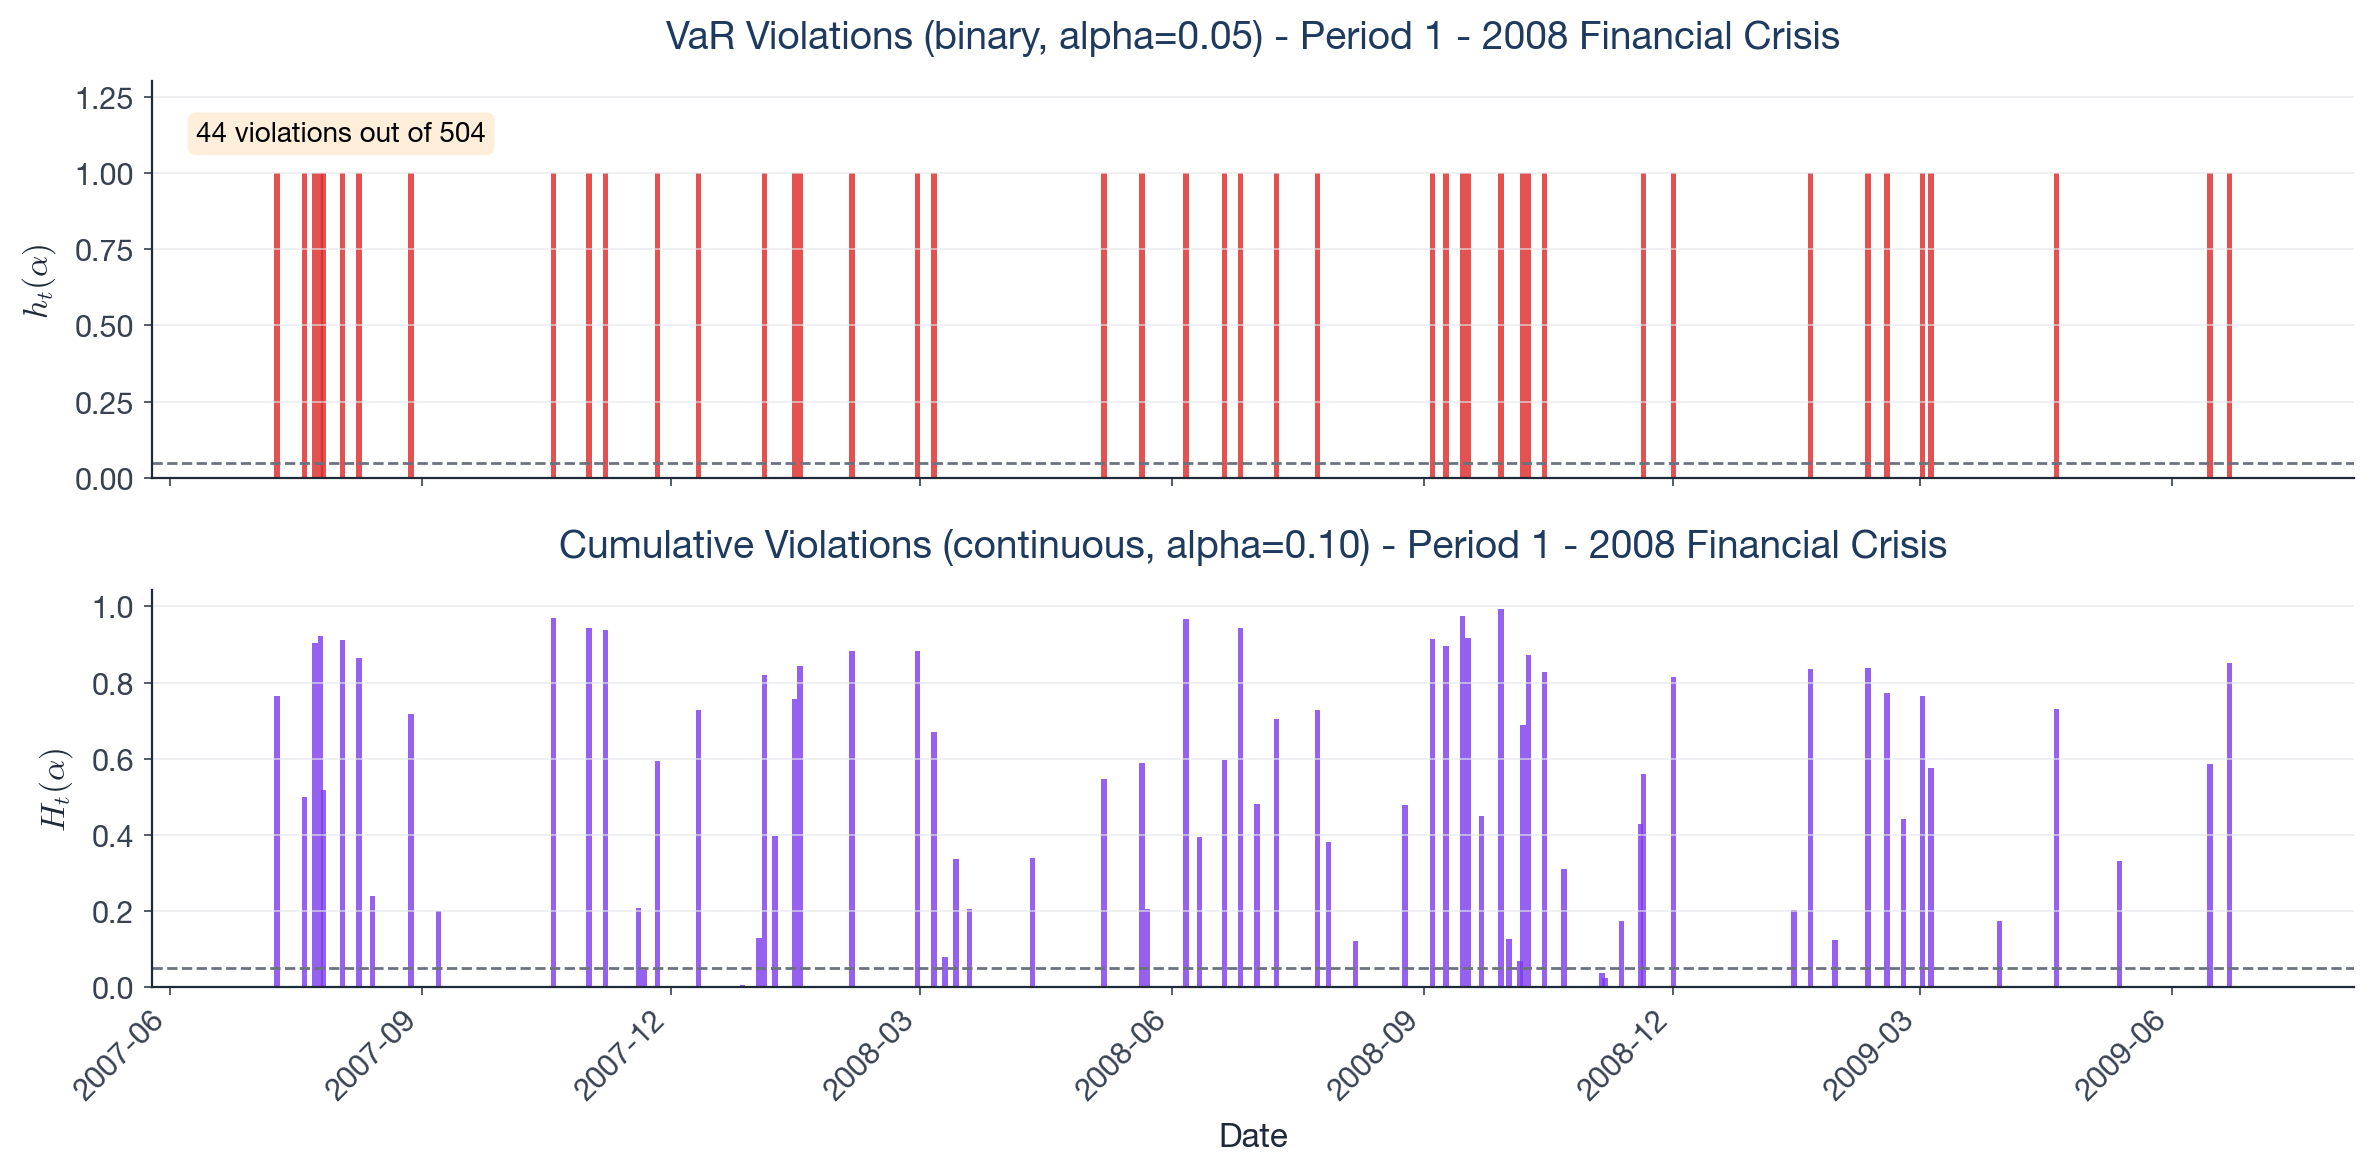

In [7]:
_ = figures.plot_violations_timeline(
    p1.forecast.oos_index,
    p1.h_t,
    p1.H_t,
    alpha_var=alpha_var,
    alpha_es=alpha_es,
    label=p1.label,
    save_to=ASSETS_FIG / "01_violations_2008.png",
)

## Conclusion

On the 2008 Financial Crisis window, **9 of the 13 tests reject at the 5 % level**; the four tests that fail to reject are `C_VaR(5)` (p=0.089), `Christoffersen_CCI` (p=0.065), `AS_Z1` (p=0.22) and `McNeil_Frey` (p=0.28). On the COVID-19 window, **10 of the 13 tests reject**; the same three tests `Christoffersen_CCI`, `AS_Z1` and `McNeil_Frey` keep p > 0.10 (0.30, 0.10 and 0.17 respectively). The marginal-coverage block (`Kupiec_POF`, `U_VaR`, `U_ES`, `KLM_multinomial(4)`) and the conditional-coverage block (`C_ES(5)`, `MU_ES`, `MC_ES(5)`, plus `C_VaR(5)` on COVID) fire on both crises, while the day-to-day independence test (`Christoffersen_CCI`) and the standardised-exceedance tests (`AS_Z1`, `McNeil_Frey`) do not detect a model violation at the level of consecutive-day pairs.

The asymmetry — the aggregate-violation component rejects even when the clustering component does not — illustrates the contrast between unconditional and conditional coverage, and is the operational case for not backtesting ES through a single statistic.